In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Part 1: Data Preparation and Exploration

In [3]:
exchange = pd.read_csv("C:/Users/shanm/Python_Practice/Datasets/exchange_rate.csv",parse_dates=['date'], index_col='date')
exchange.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [4]:
exchange.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


In [5]:
exchange.index = pd.to_datetime(exchange.index, format="%d-%m-%Y %H:%M")
exchange.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


In [6]:
exchange = exchange.asfreq('D')

In [7]:
exchange.isna().sum()

Ex_rate    0
dtype: int64

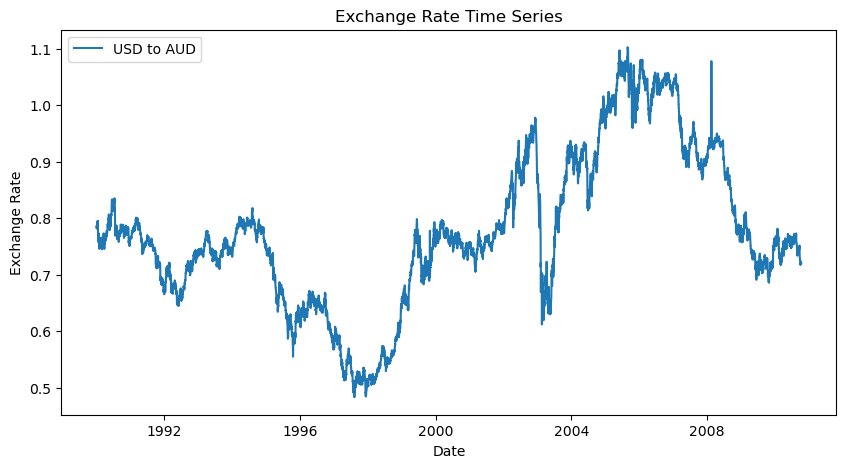

In [8]:
# Plot the exchange rate
plt.figure(figsize=(10,5))
plt.plot(exchange.iloc[:, 0], label='USD to AUD')
plt.title('Exchange Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

This indicates there is a trend component, though it changes direction over time.Lets decompose this

### ETS Decomposition

In [9]:
from statsmodels.tsa.seasonal import STL

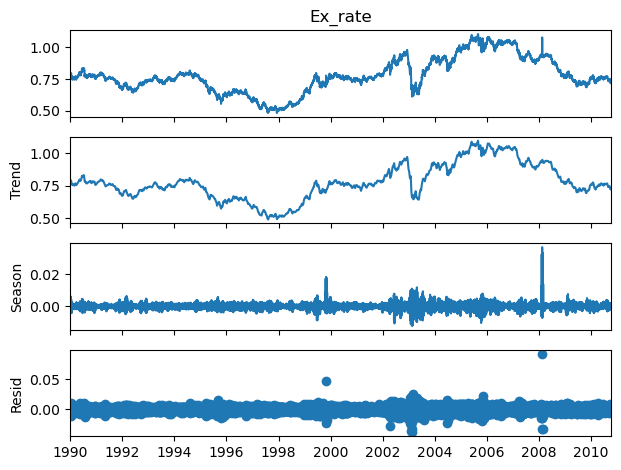

In [10]:
res = STL(exchange.iloc[:, 0] ).fit()
res.plot()
plt.show()

### Test for stationarity

In [11]:
from statsmodels.tsa.stattools import adfuller

In [12]:
adfuller(exchange.iloc[:, 0])

(-1.6649941807381343,
 0.44923273535979974,
 1,
 7586,
 {'1%': -3.4312123140180137,
  '5%': -2.861921078147796,
  '10%': -2.5669728434336108},
 -55835.06254628545)

In [13]:
def adf_test(data):
    if adfuller(data)[1] > 0.05:
        print('Data is not Stationary')
    else:
        print('Data is stationary')

In [14]:
adf_test(exchange.iloc[:, 0])

Data is not Stationary


If p-value > 0.05 then data is non-stationary, apply differencing

In [15]:
from statsmodels.tsa.statespace.tools import diff

In [16]:
diff_1 = diff(exchange, k_diff=1).dropna()

In [17]:
adf_test(diff_1)

Data is stationary


# Part 2: Model Building - ARIMA

Plotting ACF and PACF to choose q and p accordingly

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

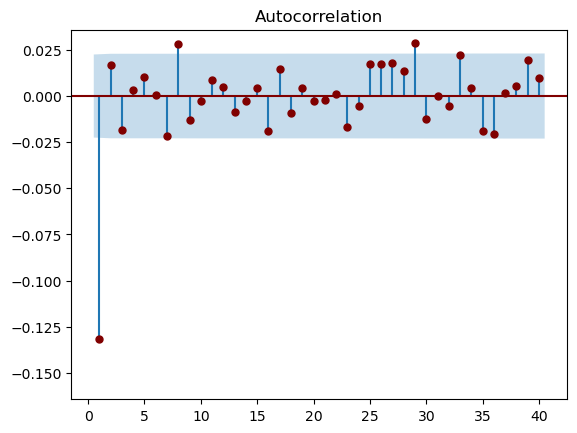

In [19]:
plot_acf(diff_1, lags=40, zero=False, 
         color="maroon",
         title='Autocorrelation',
         auto_ylims=True,
        )
plt.show()

From the above plot, we can assume q=2

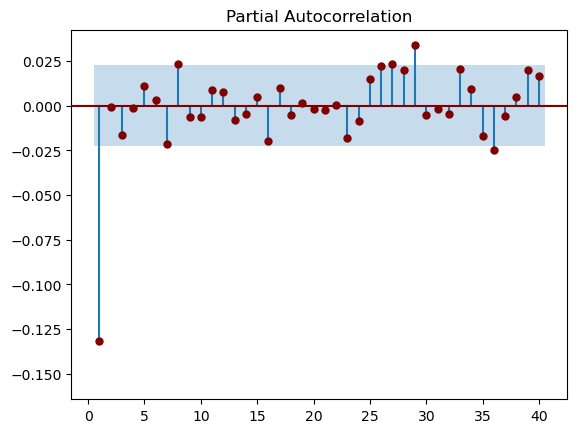

In [20]:
plot_pacf(diff_1, lags=40, zero=False, 
         color="maroon",
         title='Partial Autocorrelation',
         auto_ylims=True,
        )
plt.show()

### Find the right order

In [21]:
from pmdarima import auto_arima
from pmdarima.model_selection import train_test_split

##### Train test split

total 7588 records , 80% od 7588 = 6070 and 20% of 7588=1518

In [22]:
split = int(len(exchange) * 0.8)
train = exchange.iloc[:split, 0]
test = exchange.iloc[split:, 0]

In [23]:
train.shape, test.shape

((6070,), (1518,))

#### 1.ARIMA MODEL

1.	Parameter Selection for ARIMA: 

In [24]:
#Running the auto_arima
auto_model = auto_arima(train, start_p=0, start_q=0,
                        max_p=5, max_q=5,
                        d=None, trace=True)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-45404.538, Time=4.12 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-45424.276, Time=2.93 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-45423.258, Time=4.94 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-45406.255, Time=0.93 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-45425.953, Time=3.92 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-45430.006, Time=13.23 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=-45428.403, Time=9.96 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-45427.912, Time=6.90 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-45398.539, Time=6.99 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-45426.433, Time=6.83 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=-45431.682, Time=5.14 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=-45427.648, Time=1.76 sec
 ARIMA(4,1,0)(0,0,0)[0]             : AIC=-45430.083, Time=3.55 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-45429.587, Time=2.84 sec
 ARI

In [25]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 6070
Model:               SARIMAX(3, 1, 0)   Log Likelihood               22719.841
Date:                Thu, 23 Apr 2026   AIC                         -45431.682
Time:                        17:39:49   BIC                         -45404.838
Sample:                    01-01-1990   HQIC                        -45422.365
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0574      0.005    -11.248      0.000      -0.067      -0.047
ar.L2          0.0228      0.007      3.417      0.001       0.010       0.036
ar.L3         -0.0315      0.007     -4.661      0.000      -0.045      -0.018
sigma2       3.28e-05   1.97e-07    166.489      0.000    3.24e-05    3.32e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            101189.32
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               3.84   Skew:                            -0.72
Prob(H) (two-sided):                  0.00   Kurtosis:                        22.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
auto_model.order

(3, 1, 0)

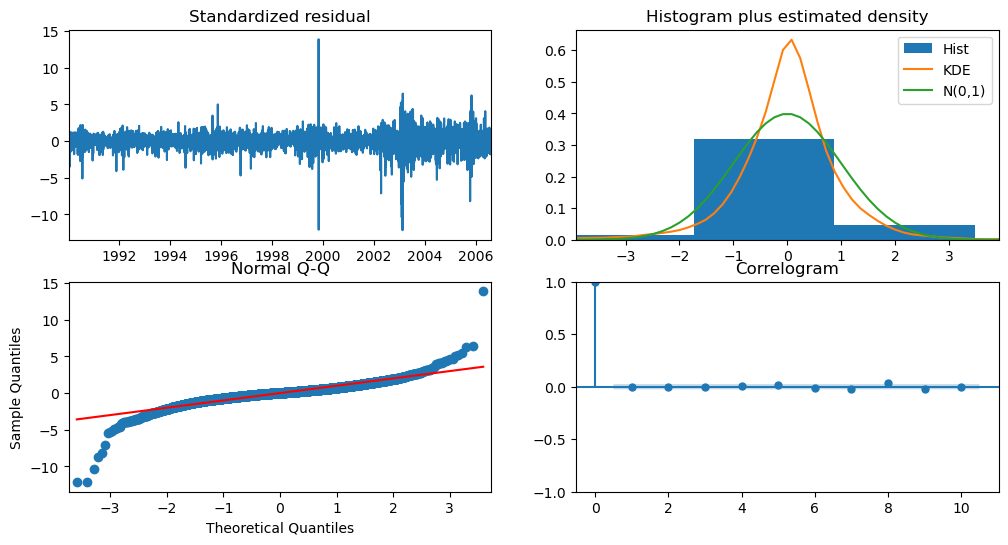

In [27]:
auto_model.plot_diagnostics(figsize=(12,6));

2.	Model Fitting

In [28]:
from statsmodels.tsa.arima.model import ARIMA
final_model = ARIMA(train,
                    order=(3,1,0)
                   )
final_output = final_model.fit()

3.	Diagnostics

Observation : 

- residual has mean 0
- residuals are normally distributed
- There exist a constant variance between errors (only fewer exceptions)
- No auto corelation exist

4.	Forecasting: 

In [29]:
forecast = final_output.forecast(steps=len(test))
forecast

2006-08-15    1.023732
2006-08-16    1.023692
2006-08-17    1.023694
2006-08-18    1.023687
2006-08-19    1.023689
                ...   
2010-10-06    1.023689
2010-10-07    1.023689
2010-10-08    1.023689
2010-10-09    1.023689
2010-10-10    1.023689
Freq: D, Name: predicted_mean, Length: 1518, dtype: float64

In [30]:
forecast.index = test.index

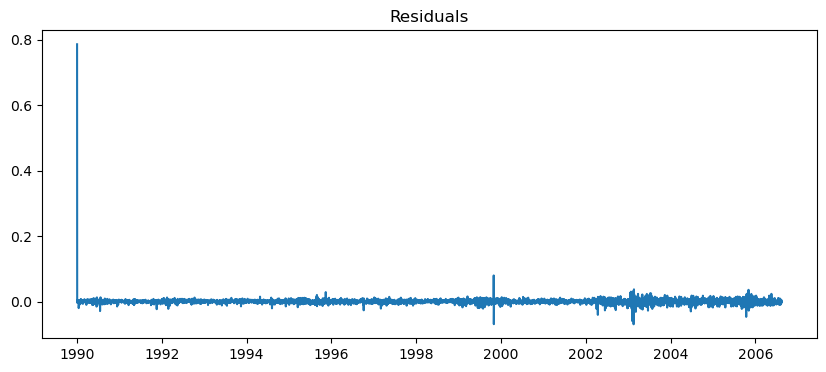

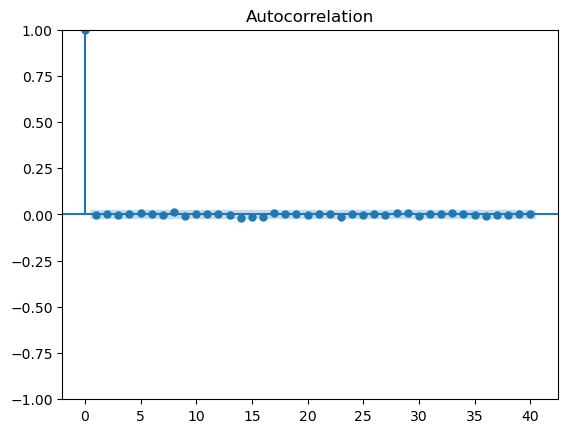

In [31]:
# Residual Analysis after fit

residuals = final_output.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals, lags=40)
plt.show()

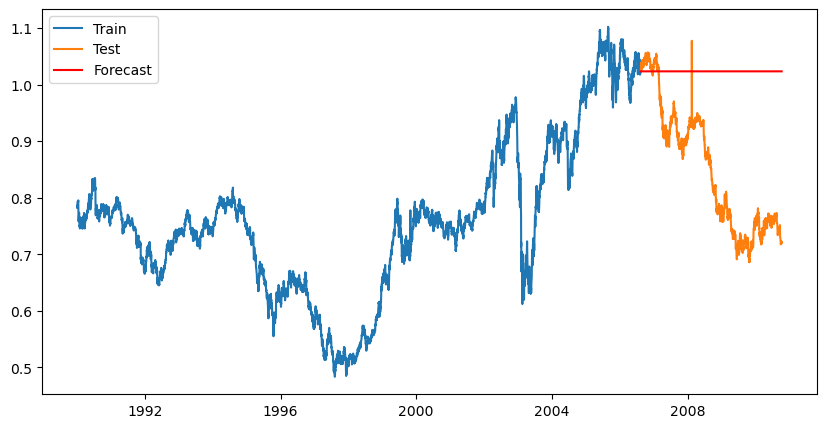

In [32]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()

Evaluation Metrics

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.17774979136682473
RMSE: 0.2054816477708252
MAPE: 22.803066504313342


#### 2.Exponential Smoothing

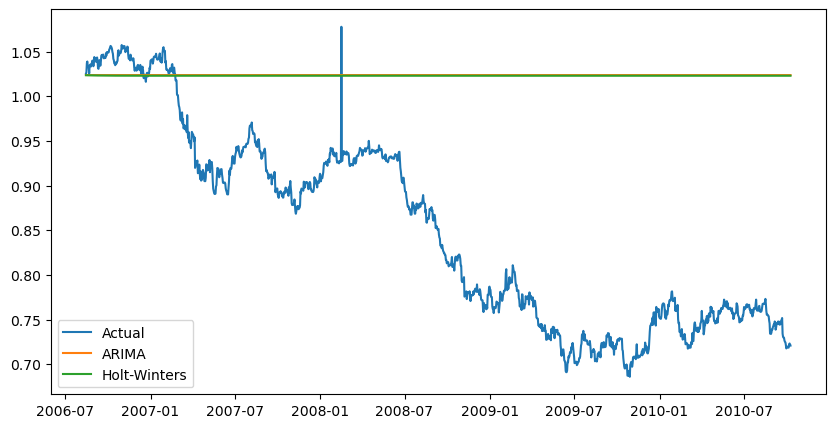

In [34]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend='add',
    damped_trend=True,
    seasonal=None).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test))
hw_forecast.index = test.index

# Plot comparison
plt.figure(figsize=(10,5))
plt.plot(test, label='Actual')
plt.plot(forecast, label='ARIMA')
plt.plot(hw_forecast, label='Holt-Winters')
plt.legend()
plt.show()

In [35]:
print(hw_model.params)

{'smoothing_level': 0.9411397541470378, 'smoothing_trend': 0.0018203794228495382, 'smoothing_seasonal': nan, 'damping_trend': 0.9707529290485644, 'initial_level': 0.7862217592412414, 'initial_trend': -0.0008938852674047529, 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


In [36]:
mae = mean_absolute_error(test, hw_forecast)
rmse = np.sqrt(mean_squared_error(test, hw_forecast))
mape = np.mean(np.abs((test - hw_forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.17717987888968484
RMSE: 0.20485529200429836
MAPE: 22.730925867803357


Observations

- The Holt-Winters model produced nearly constant forecasts despite including a trend component. This indicates that the model was unable to identify a consistent trend in the data. Exchange rate series often follow a stochastic random walk process, making them difficult to model using deterministic trend-based methods like Exponential Smoothing.
- ARIMA performed slightly better due to differencing, but forecasts still remained relatively flat, reinforcing the unpredictable nature of exchange rates.

Compare models

In [37]:
# ARIMA
mae_arima = mean_absolute_error(test, forecast)

# HW
mae_hw = mean_absolute_error(test, hw_forecast)

print("ARIMA MAE:", mae_arima)
print("HW MAE:", mae_hw)

ARIMA MAE: 0.17774979136682473
HW MAE: 0.17717987888968484


Observations
- Exchange rate shows (trend: upward)
- No strong/weak seasonality observed

ARIMA
- Works well for stationary data
- Captures autocorrelation
- Needs parameter tuning

Exponential Smoothing
- Simpler and faster
- Good for trend data
- Less flexible than ARIMA

Comparison

Comparing both ARIMA and ES , both performs equally